In [45]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import joblib
import numpy as np
import sys
import torch
from sklearn.pipeline import Pipeline
import glob
from sklearn.metrics import roc_curve, precision_recall_curve, auc
sys.path.append('..')
from src.data.preprocess import loadData, prepareFeats, splitData, buildPreprocessor
from src.models.arqMlp import ChurnMLPClassifier
df = loadData('../data/processed/telco_clean.csv')
X, y = prepareFeats(df)
X_train, X_test, y_train, y_test = splitData(X, y)
modelosBaseline = {
    'LogisticRegression': '../models/logisticregression.joblib',
    'RandomForest': '../models/randomforest.joblib',
    'GradientBoosting': '../models/gradientboosting.joblib',
    'DecisionTree': '../models/decisiontree.joblib',
}
for nome, path in modelosBaseline.items():
    pipeline = joblib.load(path)
# MLP
mlpPipeline = joblib.load('../models/pipeline_mlp_lr0_01_bs64_patience10.joblib')  


In [46]:
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
client = mlflow.tracking.MlflowClient()

# Buscar runs dos dois experimentos
runs = []
for nomeExp in ['churn-baselines', 'churn-mlp']:
    exp = client.get_experiment_by_name(nomeExp)
    if exp:
        runsExp = client.search_runs(experiment_ids=[exp.experiment_id])
        runs.extend(runsExp)

# Montar DataFrame com métricas de teste
records = []
for run in runs:
    metrics = run.data.metrics
    record = {
        'Modelo': run.info.run_name,
        'ROC-AUC': metrics.get('test_roc_auc'),
        'PR-AUC': metrics.get('test_pr_auc'),
        'Recall': metrics.get('test_recall'),
        'Precision': metrics.get('test_precision'),
        'F1': metrics.get('test_f1'),
    }
    if record['ROC-AUC'] is not None:
        records.append(record)

dfResultados = pd.DataFrame(records).sort_values('Recall', ascending=False).reset_index(drop=True)
dfResultados

,Modelo,ROC-AUC,PR-AUC,Recall,Precision,F1
0,MLP_lr1_bs64,0.789185,0.476709,0.850267,0.469719,0.605138
1,MLP_lr0_01_bs64_patience10,0.849571,0.668583,0.844920,0.479514,0.611810
2,MLP_lr0_01_bs64_patience10,0.849571,0.668583,0.844920,0.479514,0.611810
3,MLP_lr0_01_bs64_patience10,0.849571,0.668583,0.844920,0.479514,0.611810
4,MLP_lr0_01_bs64patience10,0.849571,0.668583,0.844920,0.479514,0.611810
5,MLP_lr0_1_bs64,0.852830,0.674576,0.844920,0.496075,0.625124
6,MLP_lr0_01_bs64_patience10,0.849571,0.668583,0.844920,0.479514,0.611810
7,MLP_lr0_01_bs64_patience10,0.849571,0.668583,0.844920,0.479514,0.611810
8,MLP_lr0_01_bs64,0.849571,0.668583,0.844920,0.479514,0.611810
9,MLP_lr0.1_bs64,0.852830,0.674576,0.844920,0.496075,0.625124


In [47]:
modelos_finais = [
    'MLP_lr0_01_bs64_patience10',
    'LogisticRegression',
    'RandomForest',
    'DecisionTree',
    'GradientBoosting',
    'DummyClassifier',
]

dfResultados = dfResultados[dfResultados['Modelo'].isin(modelos_finais)]\
    .drop_duplicates(subset='Modelo', keep='first')\
    .sort_values('Recall', ascending=False)\
    .reset_index(drop=True)

dfResultados

,Modelo,ROC-AUC,PR-AUC,Recall,Precision,F1
0,MLP_lr0_01_bs64_patience10,0.849571,0.668583,0.844920,0.479514,0.611810
1,LogisticRegression,0.854554,0.673010,0.796791,0.524648,0.632696
2,RandomForest,0.860007,0.677738,0.745989,0.565923,0.643599
3,DecisionTree,0.741422,0.465109,0.740642,0.469492,0.574689
4,GradientBoosting,0.850486,0.663554,0.534759,0.641026,0.583090
5,DummyClassifier,0.500000,0.265814,0.000000,0.000000,0.000000


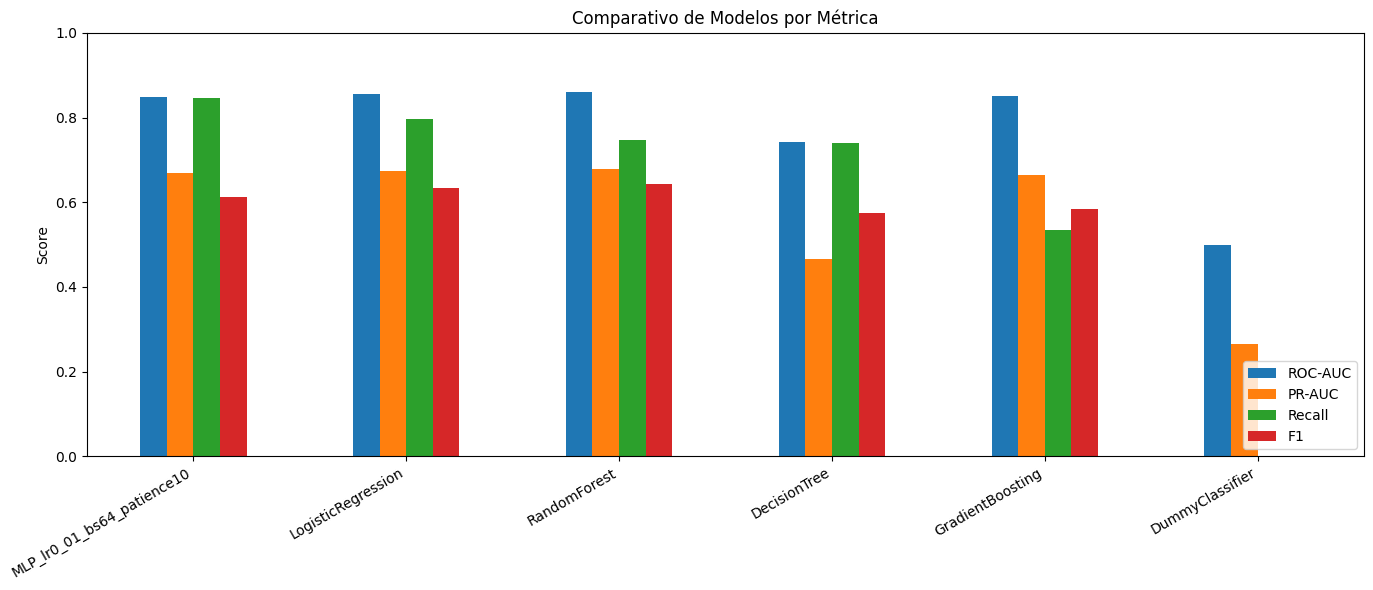

In [48]:
metricas = ['ROC-AUC', 'PR-AUC', 'Recall', 'F1']
dfPlot = dfResultados.set_index('Modelo')[metricas].astype(float)

dfPlot.plot(kind='bar', figsize=(14, 6))
plt.title('Comparativo de Modelos por Métrica')
plt.ylabel('Score')
plt.xlabel('')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
#hipoteses de custo
df = loadData('../data/processed/telco_clean.csv')
RECEITA_MENSAL = round(df['Monthly Charges'].mean(), 2)
print(f'Receita mensal média calculada do dataset: ${RECEITA_MENSAL}')
MESES_RETIDOS = 12      
RECEITA_SALVA = RECEITA_MENSAL * MESES_RETIDOS  
CUSTO_RETENCAO = RECEITA_SALVA / 10 + 40   
print(f'Hipóteses de custo:')
print(f'  Receita salva por churner evitado: ${RECEITA_SALVA}')
print(f'  Custo de ação de retenção: ${CUSTO_RETENCAO}')
print()

# Calcular custo evitado para cada modelo
n_test = len(y_test)
n_churners = y_test.sum()
#vp = verdadeiros positivos, fp = falsos positivos
print(f"{'Modelo':} {'VP':} {'FP':} {'Custo Evitado':}")
print('-' * 55)

for nome, path in modelosBaseline.items():
    try:
        pipeline = joblib.load(path)
        preds = pipeline.predict(X_test)
        vp = int(((preds == 1) & (y_test == 1)).sum())
        fp = int(((preds == 1) & (y_test == 0)).sum())
        custo = (vp * RECEITA_SALVA) - (fp * CUSTO_RETENCAO)
        print(f'{nome:} {vp:} {fp:} ${custo:,.0f}')
    except Exception:
        pass


predMlp = mlpPipeline.predict(X_test)
vp = int(((predMlp == 1) & (y_test == 1)).sum())
fp = int(((predMlp == 1) & (y_test == 0)).sum())
custo = (vp * RECEITA_SALVA) - (fp * CUSTO_RETENCAO)
print(f"{'MLP':} {vp:} {fp:} ${custo:,.0f}")

Receita mensal média calculada do dataset: $64.8
Hipóteses de custo:
  Receita salva por churner evitado: $777.5999999999999
  Custo de ação de retenção: $117.75999999999999

Modelo VP FP Custo Evitado
-------------------------------------------------------
LogisticRegression 298 270 $199,930
RandomForest 279 214 $191,750
GradientBoosting 200 112 $142,331
DecisionTree 277 313 $178,536
MLP 316 343 $205,330


## 6. Conclusão

- A **MLP** apresenta o melhor Recall — identifica mais churners que realmente churnariam, maximizando a receita salva. 
Apesar de que por usarmos um treshold de 0.5 no peso positivo da nossa loss function ou seja caso a probabilidade de churn seja de .5 ou mais sera considerado como churner por isso  identificamos muitos falsos positivos, pois consideramos que é melhor gastar com quem nao cancelaria do que deixar passar em branco (recall mais baixo) mais clientes que realmente churnariam.
- O **GradientBoosting** apesar de apresentar uma precisçao alta que os demais modelos tem o pior Recall entre os eles o que o faz ser menos adequado para o objetivo de negócio 
- A **Regressão logistica** dentre é o que mais se adequaria fora a nossa **MLP** ao nosso problema ela apresenta um recall mais alto que as demais e um pouco abaixo do modelo treinado na rede neural.

- A métrica de negócio (custo evitado) confirma que maximizar Recall é a estratégia correta dado o alto custo de perder um churner vs o baixo custo de uma ação de retenção desnecessária
